In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("churn_data.csv")
df.head()

,CustomerID,Country,State,City,Zip_Code,Latitude,Longitude,Gender,Senior_Citizen,Partner,...,Device_Protection,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,CLTV,Churn_Label,Churn_Value,Churn_Score,Churn_Reason
0,3668-QPYBK,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,No,Yes,Mailed check,53.85,108.15,3239,Yes,1,86,Competitor made better offer
1,9237-HQITU,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,No,Yes,Electronic check,70.70,151.65,2701,Yes,1,67,Moved
2,9305-CDSKC,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,Yes,Yes,Electronic check,99.65,820.5,5372,Yes,1,86,Moved
3,7892-POOKP,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Yes,Yes,Electronic check,104.80,3046.05,5003,Yes,1,84,Moved
4,0280-XJGEX,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,Yes,Yes,Bank transfer (automatic),103.70,5036.3,5340,Yes,1,89,Competitor had better devices


In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip_Code           7043 non-null   int64  
 5   Latitude           7043 non-null   float64
 6   Longitude          7043 non-null   float64
 7   Gender             7043 non-null   object 
 8   Senior_Citizen     7043 non-null   object 
 9   Partner            7043 non-null   object 
 10  Dependents         7043 non-null   object 
 11  Tenure_Months      7043 non-null   int64  
 12  Contract           7043 non-null   object 
 13  Phone_Service      7043 non-null   object 
 14  Internet_Service   7043 non-null   object 
 15  Multiple_Lines     7043 non-null   object 
 16  Streaming_TV       7043 

,Zip_Code,Latitude,Longitude,Tenure_Months,Monthly_Charges,CLTV,Churn_Value,Churn_Score
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,93521.964646,36.282441,-119.798880,32.371149,64.761692,4400.295755,0.265370,58.699418
std,1865.794555,2.455723,2.157889,24.559481,30.090047,1183.057152,0.441561,21.525131
min,90001.000000,32.555828,-124.301372,0.000000,18.250000,2003.000000,0.000000,5.000000
25%,92102.000000,34.030915,-121.815412,9.000000,35.500000,3469.000000,0.000000,40.000000
50%,93552.000000,36.391777,-119.730885,29.000000,70.350000,4527.000000,0.000000,61.000000
75%,95351.000000,38.224869,-118.043237,55.000000,89.850000,5380.500000,1.000000,75.000000
max,96161.000000,41.962127,-114.192901,72.000000,118.750000,6500.000000,1.000000,100.000000


In [7]:
df.isnull().sum()

CustomerID              0
Country                 0
State                   0
City                    0
Zip_Code                0
Latitude                0
Longitude               0
Gender                  0
Senior_Citizen          0
Partner                 0
Dependents              0
Tenure_Months           0
Contract                0
Phone_Service           0
Internet_Service        0
Multiple_Lines          0
Streaming_TV            0
Streaming_Movies        0
Online_Security         0
Tech_Support            0
Online_Backup           0
Device_Protection       0
Paperless_Billing       0
Payment_Method          0
Monthly_Charges         0
Total_Charges           0
CLTV                    0
Churn_Label             0
Churn_Value             0
Churn_Score             0
Churn_Reason         5174
dtype: int64

In [8]:
df = df.dropna()

In [9]:
columns = ['Senior_Citizen','Partner','Dependents','Phone_Service','Paperless_Billing']

for col in columns:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [10]:
df['Churn_Value'] = df['Churn_Value'].astype(int)

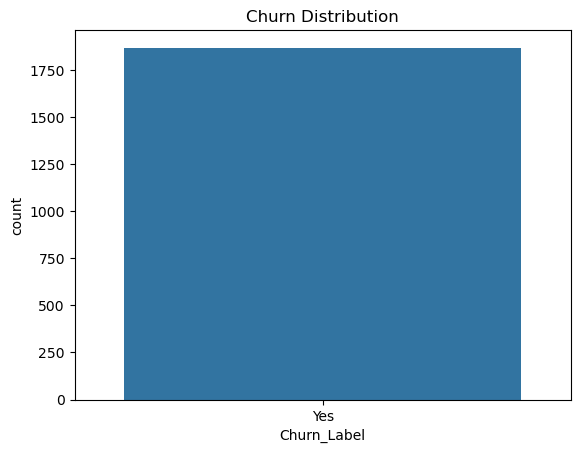

In [11]:
sns.countplot(x='Churn_Label', data=df)
plt.title("Churn Distribution")
plt.show()

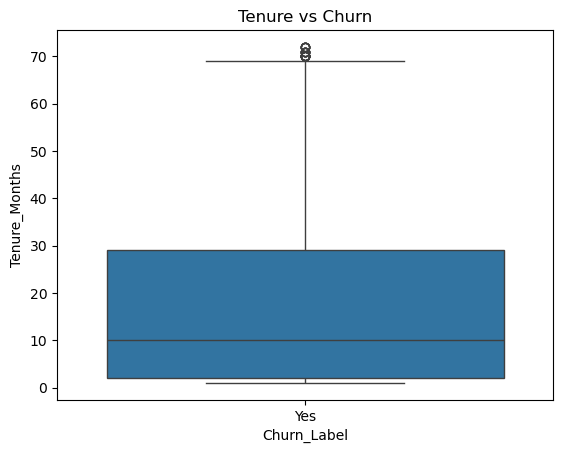

In [12]:
sns.boxplot(x='Churn_Label', y='Tenure_Months', data=df)
plt.title("Tenure vs Churn")
plt.show()

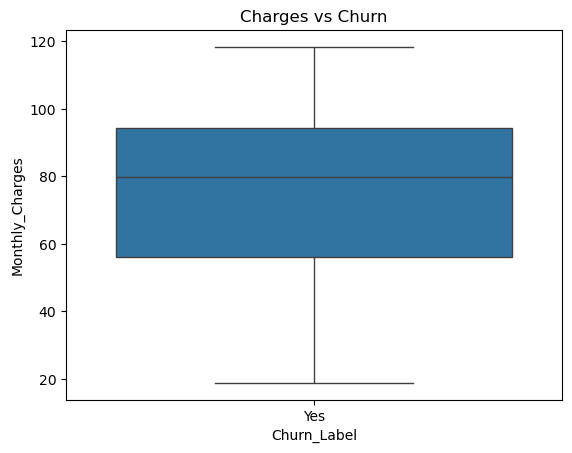

In [13]:
sns.boxplot(x='Churn_Label', y='Monthly_Charges', data=df)
plt.title("Charges vs Churn")
plt.show()

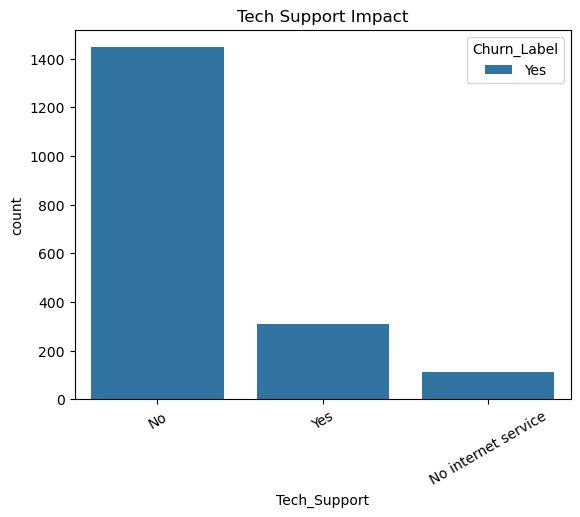

In [14]:
sns.countplot(x='Tech_Support', hue='Churn_Label', data=df)
plt.title("Tech Support Impact")
plt.xticks(rotation=30)
plt.show()

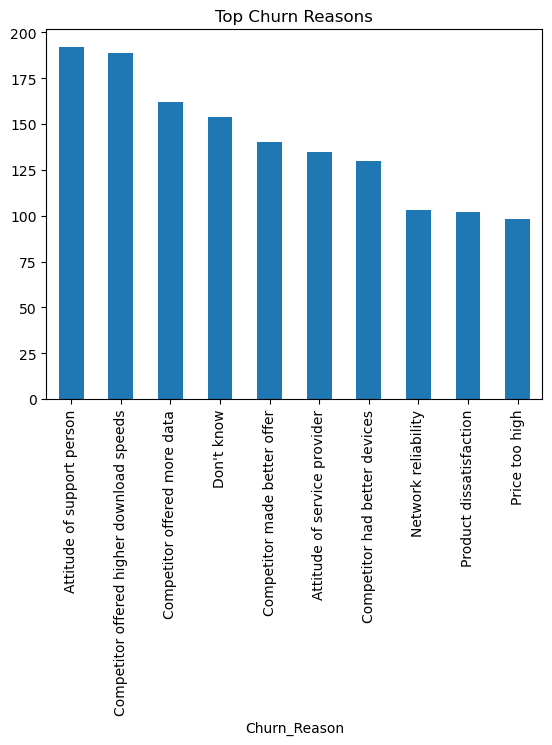

In [15]:
df['Churn_Reason'].value_counts().head(10).plot(kind='bar')
plt.title("Top Churn Reasons")
plt.show()

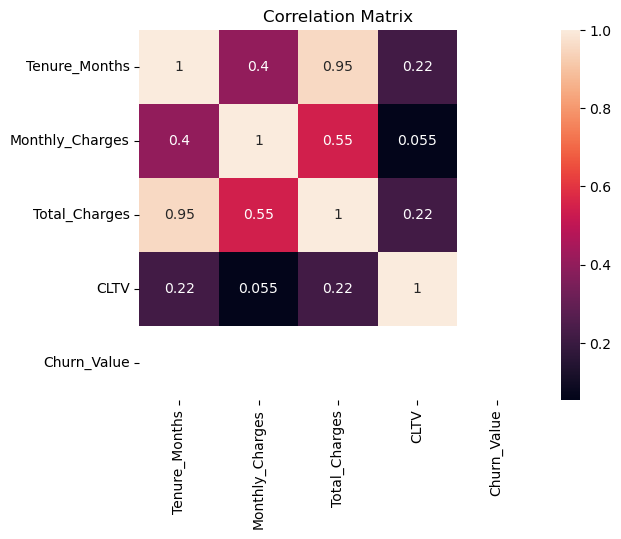

In [16]:
numeric = df[['Tenure_Months','Monthly_Charges','Total_Charges','CLTV','Churn_Value']]

sns.heatmap(numeric.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [17]:
df.to_csv("cleaned_churn.csv", index=False)